In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from pathlib import Path
from dataclasses import dataclass, asdict

# =========================
# PARAMETERS
# =========================
# Notice, we adopt a(lattice spacing)*k(momentum) = dimentionless
# v = hbar * vF / a
@dataclass
class ModelParams:
    nkx: int = 201
    nky: int = 201
    # m, v, omega are of the same unit
    tx: float = 0.0      # tilt term
    v: float = 1.0       # lattice energy scale
    m: float = 0.25      # gap-control parameter

    mu: float = 0.0      # chemical potential
    T: float = 0.01      # temperature in same energy units
    gamma: float = 0.01  # phenomenological broadening
    omega: float = 1e-3  # low-frequency probe

    force_recompute: bool = False
    cache_file: str = "cached_band_data.pkl"

params = ModelParams(
    nkx=301,
    nky=301,
    tx=0.3,     # dimentionless
    v=1.0,      # eV
    m=0.10,     # eV
    mu=0.5,     # eV
    T=0.01,     # eV
    gamma=0.01, # eV
    omega=1e-3, # eV
    force_recompute=True,
    cache_file="cached_band_data_m010_tx03.pkl"
)

In [2]:
# =========================
# PAULI MATRICES
# =========================

sigma0 = np.array([[1, 0], [0, 1]], dtype=complex)
sigmax = np.array([[0, 1], [1, 0]], dtype=complex)
sigmay = np.array([[0, -1j], [1j, 0]], dtype=complex)
sigmaz = np.array([[1, 0], [0, -1]], dtype=complex)

# =========================
# MODEL HAMILTONIAN
# =========================

def Hk(kx, ky, p: ModelParams):
    return (
         p.tx * np.sin(kx) * sigma0
        + p.v * np.sin(kx) * sigmax
        + p.v * np.sin(ky) * sigmay
        + (p.m + 2.0 - np.cos(kx) - np.cos(ky)) * sigmaz
    )

def dH_dkx(kx, ky, p: ModelParams):
    return (
         p.tx * np.cos(kx) * sigma0
        + p.v * np.cos(kx) * sigmax
        + np.sin(kx) * sigmaz
    )

def dH_dky(kx, ky, p: ModelParams):
    return (
        p.v * np.cos(ky) * sigmay
            + np.sin(ky) * sigmaz
    )

In [3]:
# =========================
# HELPERS
# =========================

def eigenshuffle(H):
    """
    Hermitian diagonalization with eigenvalues sorted ascending.
    Columns of vecs are eigenvectors.
    """
    vals, vecs = np.linalg.eigh(H)
    idx = np.argsort(vals.real)
    vals = vals[idx]
    vecs = vecs[:, idx]
    return vecs, vals

def fermi(E, mu, T):
    if T <= 0:
        return (E < mu).astype(float)
    x = (E - mu) / T
    x = np.clip(x, -700, 700)
    return 1.0 / (np.exp(x) + 1.0)

def dfermi_dE(E, mu, T):
    if T <= 0:
        raise ValueError("dfermi_dE is singular at T=0. Use small finite T.")
    f = fermi(E, mu, T)
    return -(f * (1.0 - f)) / T

def periodic_grad_x(arr, dk):
    return (np.roll(arr, -1, axis=0) - np.roll(arr, 1, axis=0)) / (2.0 * dk)

def periodic_grad_y(arr, dk):
    return (np.roll(arr, -1, axis=1) - np.roll(arr, 1, axis=1)) / (2.0 * dk)

def periodic_second_x(arr, dk):
    return (np.roll(arr, -1, axis=0) - 2.0 * arr + np.roll(arr, 1, axis=0)) / (dk**2)

def periodic_second_y(arr, dk):
    return (np.roll(arr, -1, axis=1) - 2.0 * arr + np.roll(arr, 1, axis=1)) / (dk**2)

def periodic_mixed_xy(arr, dkx, dky):
    return (
        np.roll(np.roll(arr, -1, axis=0), -1, axis=1)
        - np.roll(np.roll(arr, -1, axis=0),  1, axis=1)
        - np.roll(np.roll(arr,  1, axis=0), -1, axis=1)
        + np.roll(np.roll(arr,  1, axis=0),  1, axis=1)
    ) / (4.0 * dkx * dky)

In [4]:
# =========================
# BUILD / LOAD BAND DATA
# =========================

def build_band_data(p: ModelParams):
    cache_path = Path(p.cache_file)

    if cache_path.exists() and not p.force_recompute:
        print(f"Loading cached data from: {cache_path}")
        with open(cache_path, "rb") as f:
            return pickle.load(f)

    print("No cache found or force_recompute=True. Computing band data...")

    nbands = 2
    kx = np.linspace(-np.pi, np.pi, p.nkx, endpoint=False)
    ky = np.linspace(-np.pi, np.pi, p.nky, endpoint=False)
    dkx = kx[1] - kx[0]
    dky = ky[1] - ky[0]

    # arrays
    band = np.zeros((2, nbands, p.nkx, p.nky), dtype=complex)
    energy = np.zeros((p.nkx, p.nky, nbands), dtype=float)

    DHX = np.zeros((p.nkx, p.nky, 2, 2), dtype=complex)
    DHY = np.zeros((p.nkx, p.nky, 2, 2), dtype=complex)

    VX = np.zeros((p.nkx, p.nky, nbands, nbands), dtype=complex)
    VY = np.zeros((p.nkx, p.nky, nbands, nbands), dtype=complex)

    # diagonalization
    for ix, kxi in enumerate(kx):
        for iy, kyi in enumerate(ky):
            H = Hk(kxi, kyi, p)
            vecs, vals = eigenshuffle(H)

            band[:, :, ix, iy] = vecs
            energy[ix, iy, :] = vals.real

            DHX[ix, iy] = dH_dkx(kxi, kyi, p)
            DHY[ix, iy] = dH_dky(kxi, kyi, p)

    # sanity checks
    unnorm = np.zeros(nbands)
    unorth = np.zeros(nbands)
    eigene = np.zeros(nbands)

    for n in range(nbands):
        for ix, kxi in enumerate(kx):
            for iy, kyi in enumerate(ky):
                u_n = band[:, n, ix, iy]
                H = Hk(kxi, kyi, p)
                e_n = energy[ix, iy, n]

                unnorm[n] += abs(1.0 - np.vdot(u_n, u_n))
                eigene[n] += np.sum(np.abs(H @ u_n - e_n * u_n))

                for m in range(nbands):
                    if m == n:
                        continue
                    u_m = band[:, m, ix, iy]
                    unorth[n] += abs(np.vdot(u_n, u_m))

    print("Sanity checks:")
    print("  total unnormalization    =", np.sum(unnorm))
    print("  total unorthogonality    =", np.sum(unorth))
    print("  total eigenequation err  =", np.sum(eigene))

    tol = 1e-8
    if np.sum(unnorm) + np.sum(unorth) + np.sum(eigene) > tol:
        print("Warning: numerical errors exceed tolerance.")

    # matrix elements in band basis
    for ix in range(p.nkx):
        for iy in range(p.nky):
            U = band[:, :, ix, iy]  # columns = eigenvectors
            VX[ix, iy] = U.conj().T @ DHX[ix, iy] @ U
            VY[ix, iy] = U.conj().T @ DHY[ix, iy] @ U

    # off-diagonal Berry connections A^j_ab = i <u_a | d_{k_j} u_b>
    # for a != b:
    # <u_a|∂_j u_b> = <u_a|∂_j H|u_b> / (eps_b - eps_a)
    # so A^j_ab = i * V^j_ab / (eps_b - eps_a)
    AX = np.zeros_like(VX, dtype=complex)
    AY = np.zeros_like(VY, dtype=complex)

    for a in range(nbands):
        for b in range(nbands):
            if a == b:
                continue
            denom = energy[:, :, b] - energy[:, :, a]
            AX[:, :, a, b] = 1j * VX[:, :, a, b] / denom
            AY[:, :, a, b] = 1j * VY[:, :, a, b] / denom

    # band derivatives
    dE_dx = np.zeros_like(energy)
    dE_dy = np.zeros_like(energy)
    d2E_xx = np.zeros_like(energy)
    d2E_yy = np.zeros_like(energy)
    d2E_xy = np.zeros_like(energy)

    d3E_xxx = np.zeros_like(energy)
    d3E_yyy = np.zeros_like(energy)
    d3E_xxy = np.zeros_like(energy)
    d3E_xyy = np.zeros_like(energy)

    for n in range(nbands):
        En = energy[:, :, n]

        dE_dx[:, :, n] = periodic_grad_x(En, dkx)
        dE_dy[:, :, n] = periodic_grad_y(En, dky)

        d2E_xx[:, :, n] = periodic_second_x(En, dkx)
        d2E_yy[:, :, n] = periodic_second_y(En, dky)
        d2E_xy[:, :, n] = periodic_mixed_xy(En, dkx, dky)

        d3E_xxx[:, :, n] = periodic_grad_x(d2E_xx[:, :, n], dkx)
        d3E_yyy[:, :, n] = periodic_grad_y(d2E_yy[:, :, n], dky)
        d3E_xxy[:, :, n] = periodic_grad_y(d2E_xx[:, :, n], dky)
        d3E_xyy[:, :, n] = periodic_grad_x(d2E_yy[:, :, n], dkx)

    data = {
        "params": asdict(p),
        "kx": kx,
        "ky": ky,
        "dkx": dkx,
        "dky": dky,
        "dk_area": dkx * dky,
        "nbands": nbands,
        "band": band,
        "energy": energy,
        "DHX": DHX,
        "DHY": DHY,
        "VX": VX,
        "VY": VY,
        "AX": AX,
        "AY": AY,
        "dE_dx": dE_dx,
        "dE_dy": dE_dy,
        "d2E_xx": d2E_xx,
        "d2E_yy": d2E_yy,
        "d2E_xy": d2E_xy,
        "d3E_xxx": d3E_xxx,
        "d3E_yyy": d3E_yyy,
        "d3E_xxy": d3E_xxy,
        "d3E_xyy": d3E_xyy,
        "sanity": {
            "unnorm": unnorm,
            "unorth": unorth,
            "eigene": eigene
        }
    }

    with open(cache_path, "wb") as f:
        pickle.dump(data, f)

    print(f"Saved cache to: {cache_path}")
    return data
    
data = build_band_data(params)

No cache found or force_recompute=True. Computing band data...
Sanity checks:
  total unnormalization    = 3.1052715954160703e-11
  total unorthogonality    = 9.646458061024779e-12
  total eigenequation err  = 9.930397089244311e-11
Saved cache to: cached_band_data_m010_tx03.pkl


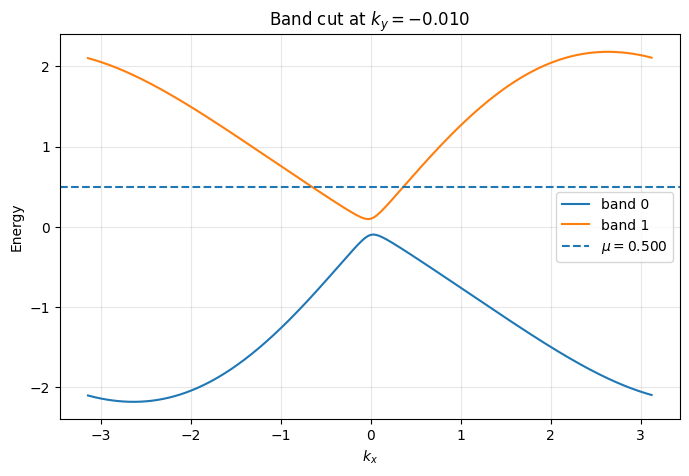

In [5]:
# =========================
# BAND STRUCTURE / FERMI LEVEL
# =========================

def plot_band_cut(data, ky_index=None, mu=None):
    kx = data["kx"]
    ky = data["ky"]
    E = data["energy"]

    if ky_index is None:
        ky_index = len(ky) // 2
    if mu is None:
        mu = data["params"]["mu"]

    plt.figure(figsize=(8, 5))
    for n in range(E.shape[2]):
        plt.plot(kx, E[:, ky_index, n], label=f"band {n}")
    plt.axhline(mu, ls="--", label=f"$\\mu={mu:.3f}$")
    plt.xlabel(r"$k_x$")
    plt.ylabel("Energy")
    plt.title(rf"Band cut at $k_y={ky[ky_index]:.3f}$")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

plot_band_cut(data)

In [6]:
# =========================
# TENSOR COMPONENT HELPERS
# =========================

def get_A_component(data, comp):
    if comp == 0:
        return data["AX"]
    elif comp == 1:
        return data["AY"]
    raise ValueError("comp must be 0 (x) or 1 (y)")

def get_dE_component(data, comp):
    if comp == 0:
        return data["dE_dx"]
    elif comp == 1:
        return data["dE_dy"]
    raise ValueError("comp must be 0 (x) or 1 (y)")

def get_d2E_component(data, a, b):
    # returns ∂^a ∂^b E
    if a == 0 and b == 0:
        return data["d2E_xx"]
    elif a == 1 and b == 1:
        return data["d2E_yy"]
    elif (a == 0 and b == 1) or (a == 1 and b == 0):
        return data["d2E_xy"]
    raise ValueError("invalid indices")

def get_d3E_component(data, a, b, c):
    idx = tuple(sorted([a, b, c]))
    if idx == (0, 0, 0):
        return data["d3E_xxx"]
    elif idx == (1, 1, 1):
        return data["d3E_yyy"]
    elif idx == (0, 0, 1):
        return data["d3E_xxy"]
    elif idx == (0, 1, 1):
        return data["d3E_xyy"]
    raise ValueError("invalid indices")

Here we compute
$(\hat{\sigma}^1_\Omega)_{\gamma j} = -\frac{e^2}{\hbar}\int_\mathbf{k} \sum_{ab}\left(-\delta_{ab}\frac{if_a \partial^j\partial^\gamma \epsilon_a}{\hbar\Omega+i\Gamma}+if_{ba}A^{j}_{ab}A^\gamma_{ba}\right)$

Notice, the dimention of this conductivity is $e^2/\hbar$ which is the same as $c\varepsilon_0$, with $e^2/(\hbar c\varepsilon_0) = 0.09170123610074787$

In [7]:
# =========================
# LINEAR CONDUCTIVITY
# =========================

def sigma1(n, data, omega=None, gamma=None, mu=None, T=None, e_charge=1.0, hbar=1.0):
    p = data["params"]
    if omega is None:
        omega = p["omega"]
    if gamma is None:
        gamma = p["gamma"]
    if mu is None:
        mu = p["mu"]
    if T is None:
        T = p["T"]

    E = data["energy"]
    nbands = data["nbands"]
    weight = data["dk_area"] / (2.0 * np.pi)**2

    f = fermi(E, mu, T)

    sig = np.zeros((2, 2), dtype=complex)
    denom_intra = (n * omega + 1j * gamma)

    for gamma_idx in range(2):
        A_gamma = get_A_component(data, gamma_idx)
        for j_idx in range(2):
            A_j = get_A_component(data, j_idx)

            total = 0.0 + 0.0j

            # diagonal / intraband part
            d2E = get_d2E_component(data, j_idx, gamma_idx)
            for a in range(nbands):
                total += np.sum(
                    -1j * f[:, :, a] * d2E[:, :, a] / denom_intra
                )

            # off-diagonal / interband part
            for a in range(nbands):
                for b in range(nbands):
                    if a == b:
                        continue
                    f_ba = f[:, :, b] - f[:, :, a]
                    total += np.sum(
                        1j * f_ba * A_j[:, :, a, b] * A_gamma[:, :, b, a]
                    )

            sig[gamma_idx, j_idx] = -(e_charge / hbar) * weight * total

    return sig
scaler = 0.09170123610074787    
sig1 = scaler * sigma1(1, data) # conductivity in units of epsilon_0 c
print(sig1)

[[ 0.35781016+3.57810164e-02j  0.00420327+5.74853453e-18j]
 [-0.00420327+5.74087227e-18j  0.36934183+3.69341831e-02j]]


In [8]:
sig12 = scaler * sigma1(2, data) # conductivity in units of epsilon_0 c
print(sig1)

[[ 0.35781016+3.57810164e-02j  0.00420327+5.74853453e-18j]
 [-0.00420327+5.74087227e-18j  0.36934183+3.69341831e-02j]]


Now $(\hat{\sigma}^2_{\Omega,\Omega})_{\gamma ij} =\frac{e^3}{\hbar}\sum_{ab}\Bigg\{
    -\frac{\delta_{ab}f_a \partial^j\partial^i\partial^\gamma \epsilon_a}{(2\hbar\Omega+i\Gamma)(\hbar\Omega+i\Gamma)}+\frac{iA^\gamma_{ba} A^{i}_{ab}i\partial^jf_{ba}}{\hbar\Omega+i\Gamma}\Bigg\}$

In [9]:
# =========================
# SECOND-ORDER CONDUCTIVITY
# =========================

def sigma2(data, omega=None, gamma=None, mu=None, T=None, e_charge=1.0, hbar=1.0):
    p = data["params"]
    if omega is None:
        omega = p["omega"]
    if gamma is None:
        gamma = p["gamma"]
    if mu is None:
        mu = p["mu"]
    if T is None:
        T = p["T"]

    E = data["energy"]
    nbands = data["nbands"]
    weight = data["dk_area"] / (2.0 * np.pi)**2

    f = fermi(E, mu, T)
    fp = dfermi_dE(E, mu, T)

    sig = np.zeros((2, 2, 2), dtype=complex)

    denom1 = (2.0 * omega + 1j * gamma) * (omega + 1j * gamma)
    denom2 = (omega + 1j * gamma)

    for gamma_idx in range(2):
        A_gamma = get_A_component(data, gamma_idx)

        for i_idx in range(2):
            A_i = get_A_component(data, i_idx)

            for j_idx in range(2):
                dE_j = get_dE_component(data, j_idx)
                d3E = get_d3E_component(data, j_idx, i_idx, gamma_idx)

                total = 0.0 + 0.0j

                # diagonal / intraband term
                for a in range(nbands):
                    total += np.sum(
                        -f[:, :, a] * d3E[:, :, a] / denom1
                    )

                # off-diagonal term
                for a in range(nbands):
                    for b in range(nbands):
                        if a == b:
                            continue

                        dfba_dj = (
                            fp[:, :, b] * dE_j[:, :, b]
                            - fp[:, :, a] * dE_j[:, :, a]
                        )

                        total += np.sum(
                            (1j * A_gamma[:, :, b, a]) * (1j * A_i[:, :, a, b]) * dfba_dj / denom2
                        )

                sig[gamma_idx, i_idx, j_idx] = (e_charge**2 / hbar**2) * weight * total

    return sig
    
sig2 = scaler * sigma2(data) # divide by eps_0*c

def pretty_matrix(M, name):
    print(f"{name}:")
    for row in M:
        print("  ", ["{:.2f}{:+.2f}j".format(x.real, x.imag) for x in row])
    print()

pretty_matrix(sig2[0], "σ_x")
pretty_matrix(sig2[1], "σ_y")

σ_x:
   ['13.83+4.23j', '-0.00-0.00j']
   ['0.07+0.01j', '3.19+0.98j']

σ_y:
   ['-0.07-0.01j', '3.19+0.98j']
   ['3.19+0.98j', '-0.00-0.00j']



Unit of this conductivity is [m/V]*(a in meters) = [m/V]*$10^{-9}$. Multiplied with the amplitude of the EF is V/m results in dimentionless value  

In [11]:
import numpy as np

def normalize_vector(v, tol=1e-14):
    v = np.asarray(v, dtype=float)
    n = np.linalg.norm(v)
    if n < tol:
        raise ValueError("Direction vector nE has near-zero norm.")
    return v / n


def sigma2_contract(sig2, E):
    """
    Contract second-order conductivity tensor with E_i E_j:
        out_gamma = sum_{i,j} sig2[gamma,i,j] E[i] E[j]

    sig2 shape: (2,2,2)
    E shape: (2,)
    returns shape: (2,)
    """
    return np.einsum("gij,i,j->g", sig2, E, E)


def transmitted_harmonics(sig1_omega,
                           sig1_2omega,
                           sig2_omegaomega,
                           E0_Vm,
                           nE=(1.0, 0.0),
                           E_scale=1.0, # in V/m
                           a_g = 1e-9,  # lattice const in m
                           return_physical=False):
    """
    Compute transmitted first and second harmonic fields.

    Parameters
    ----------
    sig1_omega : array_like, shape (2,2)
        Linear conductivity tensor at omega, in units of eps0*c.
    sig1_2omega : array_like, shape (2,2)
        Linear conductivity tensor at 2*omega, in units of eps0*c.
    sig2_omegaomega : array_like, shape (2,2,2)
        Second-order conductivity tensor in the user's normalized units.
    E0_Vm : float
        Incident electric-field amplitude in V/m.
    nE : tuple/list/array, shape (2,)
        Incident polarization direction.
    E_scale : float
        Field scale converting V/m into the dimensionless field used in sig2:
            E_dimless = E_physical / E_scale
    return_physical : bool
        If True, also return physical transmitted fields in V/m
        using the same E_scale.

    Returns
    -------
    result : dict
        Contains:
        - E1_in_dimless
        - E1_t_dimless
        - E2_t_dimless
        and optionally:
        - E1_in_Vm
        - E1_t_Vm
        - E2_t_Vm
    """
    sig1_omega = np.asarray(sig1_omega, dtype=complex)
    sig1_2omega = np.asarray(sig1_2omega, dtype=complex)
    sig2_omegaomega = np.asarray(sig2_omegaomega, dtype=complex)

    nE = normalize_vector(nE)

    # incident field
    E1_in_Vm = E0_Vm * nE
    E1_in_dimless = E1_in_Vm / E_scale

    I2 = np.eye(2, dtype=complex)

    # First harmonic:
    # E1_t = (1 + sig1(omega)/2)^(-1) E1_in
    M1 = I2 + 0.5 * sig1_omega
    E1_t_dimless = np.linalg.solve(M1, E1_in_dimless)

    # Nonlinear source vector:
    # S_gamma = sum_{ij} sig2[gamma,i,j] E1_t[i] E1_t[j]
    source2 = sigma2_contract(sig2_omegaomega, E1_t_dimless) * a_g * E_scale

    # Second harmonic:
    # E2_t = -(1/2) (1 + sig1(2omega)/2)^(-1) source2
    M2 = I2 + 0.5 * sig1_2omega
    E2_t_dimless = -0.5 * np.linalg.solve(M2, source2)

    result = {
        "E1_in_dimless": E1_in_dimless,
        "E1_t_dimless": E1_t_dimless,
        "E2_t_dimless": E2_t_dimless,
    }

    if return_physical:
        result["E1_in_Vm"] = E1_in_Vm
        result["E1_t_Vm"] = E1_t_dimless * E_scale
        result["E2_t_Vm"] = E2_t_dimless * E_scale

    return result

result = transmitted_harmonics(
    sig1_omega=sig1,
    sig1_2omega=sig12,
    sig2_omegaomega=sig2,
    E0_Vm=1e5,
    nE=(1.0, 0.0),
    E_scale=1e9,   # example only; set your actual field normalization
    return_physical=True
)

print("E1 incident (dimless) =", result["E1_in_dimless"])
print("E1 transmitted (dimless) =", result["E1_t_dimless"])
print("E2 transmitted (dimless) =", result["E2_t_dimless"])

print("E1 incident (V/m) =", result["E1_in_Vm"])
print("E1 transmitted (V/m) =", result["E1_t_Vm"])
print("E2 transmitted (V/m) =", result["E2_t_Vm"])

E1 incident (dimless) = [0.0001 0.    ]
E1 transmitted (dimless) = [8.48046729e-05-1.28694752e-06j 1.50373499e-07-4.62715548e-09j]
E2 transmitted (dimless) = [-4.30595572e-08-1.04058544e-08j  9.38074878e-11-1.60637977e-11j]
E1 incident (V/m) = [100000.      0.]
E1 transmitted (V/m) = [84804.67286452-1286.94751974j   150.37349889   -4.62715548j]
E2 transmitted (V/m) = [-43.0595572 -10.40585443j   0.09380749 -0.0160638j ]
